
# Proyek Analisis Data: Bike_sharing_dataset

Nama: Agil Aryanusa

Email: akuagil3@gmail.com

ID Dicoding: igell28

##Menentukan Pertanyaan Bisnis


---


*   Faktor apa yang paling mempengaruhi jumlah penyewaan sepeda
(cnt) secara harian dan per jam?
*   Bagaimana pola penggunaan sepeda berdasarkan waktu (jam, hari dalam seminggu, dan musim)?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load dataset

In [2]:
df = pd.read_csv("day.csv", delimiter=",")
df = pd.read_csv("hour.csv", delimiter=",")

## DATA WRANGLING

### Gathering Data

In [3]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### **ASSESSING DATA**

In [5]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### **Cleaning Data**

In [11]:
day_df = pd.read_csv("day.csv")

day_df.drop_duplicates(inplace=True)

print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [12]:
day_df[day_df.hum.isna()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [13]:
day_df.hum.value_counts()

,count
hum,
0.613333,4
0.605000,3
0.590000,3
0.538333,3
0.690000,3
...,...
0.548333,1
0.561765,1
0.850000,1


In [14]:
day_df.fillna(value="Prefer not to say", inplace=True)

In [15]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
day_df.info()

In [16]:
day_df[day_df.hum == day_df.hum.max()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
265,266,2011-09-23,4,0,9,0,5,1,2,0.609167,0.522125,0.9725,0.078367,258,2137,2395


In [17]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [18]:
hour_df.drop_duplicates(inplace=True)

In [19]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [20]:
hour_df.hum.value_counts()

,count
hum,
0.88,657
0.83,630
0.94,560
0.87,488
0.70,430
...,...
0.12,1
0.08,1
0.10,1


In [21]:
hour_df.fillna(value="Prefer not to say", inplace=True)

In [22]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [23]:
hour_df[hour_df.hum == hour_df.hum.max()]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
26,27,2011-01-02,1,0,1,2,0,0,0,2,0.42,0.4242,1.0,0.2836,1,8,9
721,722,2011-02-02,1,0,2,10,0,3,1,2,0.22,0.2727,1.0,0.0000,2,59,61
786,787,2011-02-05,1,0,2,5,0,6,0,3,0.20,0.2273,1.0,0.0896,0,9,9
787,788,2011-02-05,1,0,2,6,0,6,0,3,0.20,0.2576,1.0,0.0000,0,4,4
789,790,2011-02-05,1,0,2,8,0,6,0,3,0.20,0.2273,1.0,0.0896,0,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16865,16866,2012-12-10,4,1,12,12,0,1,1,3,0.44,0.4394,1.0,0.2239,23,150,173
16866,16867,2012-12-10,4,1,12,13,0,1,1,3,0.44,0.4394,1.0,0.2239,30,190,220
17025,17026,2012-12-17,4,1,12,4,0,1,1,3,0.36,0.3788,1.0,0.0000,2,3,5
17319,17320,2012-12-29,1,1,12,12,0,6,0,3,0.20,0.2424,1.0,0.0000,5,43,48


In [24]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## Exploratory Data Analysis (EDA)

In [25]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [26]:
grouped_season = day_df.groupby(by="season").agg({
    "cnt": ["sum", "mean", "max", "min"],
    "registered": ["sum", "mean", "max", "min"],
    "casual": ["sum", "mean", "max", "min"]
})

grouped_season

cnt                          registered                          \
            sum         mean   max   min        sum         mean   max  min   
season                                                                        
1        471348  2604.132597  7836   431     410726  2269.204420  5315  416   
2        918589  4992.331522  8362   795     715067  3886.233696  6456  674   
3       1061129  5644.303191  8714  1115     835038  4441.691489  6917  889   
4        841613  4728.162921  8555    22     711831  3999.050562  6946   20   

        casual                          
           sum         mean   max  min  
season                                  
1        60622   334.928177  3155    9  
2       203522  1106.097826  3410  120  
3       226091  1202.611702  3160  118  
4       129782   729.112360  3031    2

In [27]:
grouped_season_sorted = (
    day_df.groupby(by="season")
    .agg({
        "cnt": ["sum", "mean", "max", "min"],
        "registered": ["sum", "mean", "max", "min"],
        "casual": ["sum", "mean", "max", "min"]
    })
    .sort_values(by=("cnt", "sum"), ascending=False)  # Sorting by total rentals in descending order
)

grouped_season_sorted

cnt                          registered                          \
            sum         mean   max   min        sum         mean   max  min   
season                                                                        
3       1061129  5644.303191  8714  1115     835038  4441.691489  6917  889   
2        918589  4992.331522  8362   795     715067  3886.233696  6456  674   
4        841613  4728.162921  8555    22     711831  3999.050562  6946   20   
1        471348  2604.132597  7836   431     410726  2269.204420  5315  416   

        casual                          
           sum         mean   max  min  
season                                  
3       226091  1202.611702  3160  118  
2       203522  1106.097826  3410  120  
4       129782   729.112360  3031    2  
1        60622   334.928177  3155    9



---------------------------------------------





In [28]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [29]:
grouped_hour = hour_df.groupby(by="hr").agg({
    "cnt": ["sum", "mean", "max", "min"],
    "registered": ["sum", "mean", "max", "min"],
    "casual": ["sum", "mean", "max", "min"]
})

grouped_hour

cnt                      registered                      casual  \
       sum        mean  max min        sum        mean  max min    sum   
hr                                                                       
0    39130   53.898072  283   2      31755   43.739669  234   0   7375   
1    24164   33.375691  168   1      19455   26.871547  139   0   4709   
2    16352   22.869930  132   1      12940   18.097902  104   0   3412   
3     8174   11.727403   79   1       6281    9.011478   61   0   1893   
4     4428    6.352941   28   1       3554    5.098996   22   0    874   
5    14261   19.889819   66   1      13249   18.478382   64   0   1012   
6    55132   76.044138  213   1      52115   71.882759  203   0   3017   
7   154171  212.064649  596   1     146134  201.009629  572   1   8037   
8   261001  359.011004  839   5     245240  337.331499  808   4  15761   
9   159438  219.309491  426  14     136980  188.418157  399   6  22458   
10  126257  173.668501  539   8      92468  127.191197  351   8  33789   
11  151320  208.143054  663  10     108034  148.602476  446   5  43286   
12  184414  253.315934  776   3     134696  185.021978  526   3  49718   
13  184919  253.661180  760  11     132206  181.352538  491   9  52713   
14  175652  240.949246  750  12     120563  165.381344  502  12  55089   
15  183149  251.233196  750   7     128543  176.327846  456   4  54606   
16  227748  311.983562  783  11     173914  238.238356  481   8  53834   
17  336860  461.452055  976  15     282640  387.178082  885  14  54220   
18  309772  425.510989  977  23     265276  364.390110  886  20  44496   
19  226789  311.523352  743  11     191284  262.752747  662  11  35505   
20  164550  226.030220  567  11     138172  189.796703  461   8  26378   
21  125445  172.314560  584   6     104875  144.059066  362   6  20570   
22   95612  131.335165  502   9      79412  109.082418  327   5  16200   
23   63941   87.831044  256   2      52876   72.631868  220   2  11065   

                        
         mean  max min  
hr                      
0   10.158402   68   0  
1    6.504144   49   0  
2    4.772028   44   0  
3    2.715925   26   0  
4    1.253945   13   0  
5    1.411437   16   0  
6    4.161379   19   0  
7   11.055021   40   0  
8   21.679505   69   0  
9   30.891334  142   0  
10  46.477304  209   0  
11  59.540578  268   0  
12  68.293956  362   0  
13  72.308642  355   0  
14  75.567901  361   0  
15  74.905350  357   0  
16  73.745205  367   0  
17  74.273973  347   0  
18  61.120879  266   0  
19  48.770604  230   0  
20  36.233516  237   0  
21  28.255495  222   0  
22  22.252747  175   0  
23  15.199176   71   0

In [30]:
grouped_hour_sorted = (
    hour_df.groupby(by="hr")
    .agg({
        "cnt": ["sum", "mean", "max", "min"],
        "registered": ["sum", "mean", "max", "min"],
        "casual": ["sum", "mean", "max", "min"]
    })
    .sort_values(by=("cnt", "sum"), ascending=False)  # Sorting by total rentals in descending order
)

grouped_hour_sorted

cnt                      registered                      casual  \
       sum        mean  max min        sum        mean  max min    sum   
hr                                                                       
17  336860  461.452055  976  15     282640  387.178082  885  14  54220   
18  309772  425.510989  977  23     265276  364.390110  886  20  44496   
8   261001  359.011004  839   5     245240  337.331499  808   4  15761   
16  227748  311.983562  783  11     173914  238.238356  481   8  53834   
19  226789  311.523352  743  11     191284  262.752747  662  11  35505   
13  184919  253.661180  760  11     132206  181.352538  491   9  52713   
12  184414  253.315934  776   3     134696  185.021978  526   3  49718   
15  183149  251.233196  750   7     128543  176.327846  456   4  54606   
14  175652  240.949246  750  12     120563  165.381344  502  12  55089   
20  164550  226.030220  567  11     138172  189.796703  461   8  26378   
9   159438  219.309491  426  14     136980  188.418157  399   6  22458   
7   154171  212.064649  596   1     146134  201.009629  572   1   8037   
11  151320  208.143054  663  10     108034  148.602476  446   5  43286   
10  126257  173.668501  539   8      92468  127.191197  351   8  33789   
21  125445  172.314560  584   6     104875  144.059066  362   6  20570   
22   95612  131.335165  502   9      79412  109.082418  327   5  16200   
23   63941   87.831044  256   2      52876   72.631868  220   2  11065   
6    55132   76.044138  213   1      52115   71.882759  203   0   3017   
0    39130   53.898072  283   2      31755   43.739669  234   0   7375   
1    24164   33.375691  168   1      19455   26.871547  139   0   4709   
2    16352   22.869930  132   1      12940   18.097902  104   0   3412   
5    14261   19.889819   66   1      13249   18.478382   64   0   1012   
3     8174   11.727403   79   1       6281    9.011478   61   0   1893   
4     4428    6.352941   28   1       3554    5.098996   22   0    874   

                        
         mean  max min  
hr                      
17  74.273973  347   0  
18  61.120879  266   0  
8   21.679505   69   0  
16  73.745205  367   0  
19  48.770604  230   0  
13  72.308642  355   0  
12  68.293956  362   0  
15  74.905350  357   0  
14  75.567901  361   0  
20  36.233516  237   0  
9   30.891334  142   0  
7   11.055021   40   0  
11  59.540578  268   0  
10  46.477304  209   0  
21  28.255495  222   0  
22  22.252747  175   0  
23  15.199176   71   0  
6    4.161379   19   0  
0   10.158402   68   0  
1    6.504144   49   0  
2    4.772028   44   0  
5    1.411437   16   0  
3    2.715925   26   0  
4    1.253945   13   0

In [31]:
active_dates = hour_df.dteday.unique().tolist()
day_df["status"] = day_df["dteday"].apply(lambda x: "Active" if x in active_dates else "Non Active")
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,status
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822,Active
180,181,2011-06-30,3,0,6,0,4,1,1,0.696667,0.637008,0.434167,0.185312,1027,4488,5515,Active
340,341,2011-12-07,4,0,12,0,3,1,3,0.410000,0.400246,0.970417,0.266175,50,655,705,Active
477,478,2012-04-22,2,1,4,0,0,0,3,0.396667,0.389504,0.835417,0.344546,120,907,1027,Active
47,48,2011-02-17,1,0,2,0,4,1,1,0.435833,0.428658,0.505000,0.230104,259,2216,2475,Active


In [32]:
status_counts = day_df.groupby(by="status").dteday.count()
status_counts

,dteday
status,
Active,731


In [33]:
day_hour_merged = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    left_on="dteday",
    right_on="dteday"
)

day_hour_merged.head()


,instant_x,dteday,season_x,yr_x,mnth_x,hr,holiday_x,weekday_x,workingday_x,weathersit_x,...,workingday_y,weathersit_y,temp_y,atemp_y,hum_y,windspeed_y,casual_y,registered_y,cnt_y,status
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Active
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Active
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Active
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Active
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Active


In [34]:
day_hour_merged.columns

Index(['instant_x', 'dteday', 'season_x', 'yr_x', 'mnth_x', 'hr', 'holiday_x',
       'weekday_x', 'workingday_x', 'weathersit_x', 'temp_x', 'atemp_x',
       'hum_x', 'windspeed_x', 'casual_x', 'registered_x', 'cnt_x',
       'instant_y', 'season_y', 'yr_y', 'mnth_y', 'holiday_y', 'weekday_y',
       'workingday_y', 'weathersit_y', 'temp_y', 'atemp_y', 'hum_y',
       'windspeed_y', 'casual_y', 'registered_y', 'cnt_y', 'status'],
      dtype='object')

In [35]:
season_orders_fixed = (
    day_hour_merged.groupby(by="season_y")
    .dteday.nunique()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)  # Menampilkan 10 hasil teratas
)

season_orders_fixed

,season_y,dteday
0,3,188
1,2,184
2,1,181
3,4,178


## Visualization & Explanatory Analysis

### Pertanyaan 1:

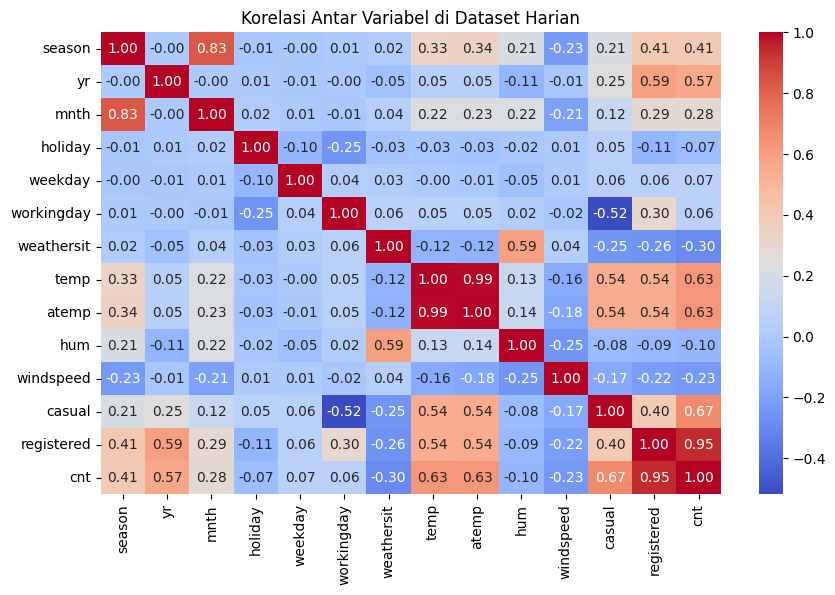

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(day_df.select_dtypes(include=np.number).drop(columns=['instant']).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Variabel di Dataset Harian")
plt.show()

### Pertanyaan 2:

<ipython-input-37-4018a1349adb>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=hour_df, x="hr", y="cnt", estimator='mean', ci=None)


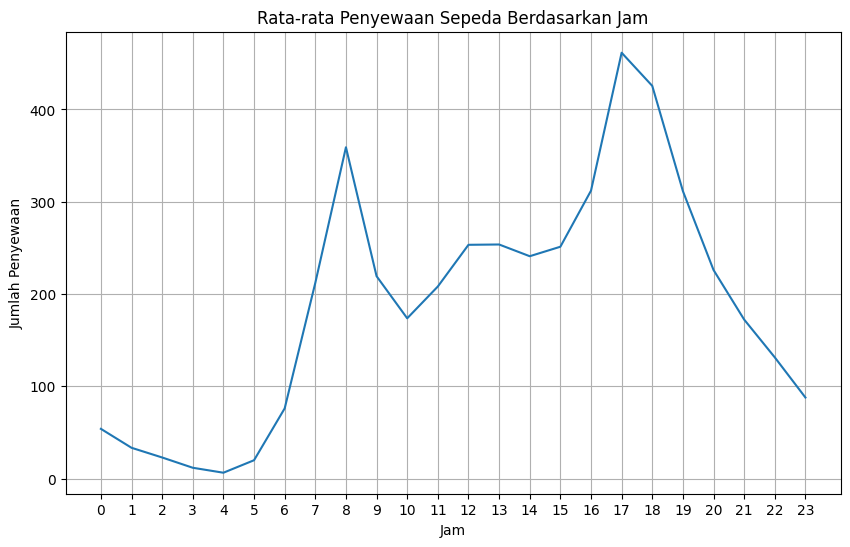

In [37]:
plt.figure(figsize=(10,6))
sns.lineplot(data=hour_df, x="hr", y="cnt", estimator='mean', ci=None)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Penyewaan")
plt.xticks(range(0,24))
plt.grid()
plt.show()

## Analisis Lanjutan (Opsional)

### Visualisasi jumlah penyewaan berdasarkan hari dalam seminggu

<ipython-input-38-df0440857cfb>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=day_df, x="weekday", y="cnt", ci=None)


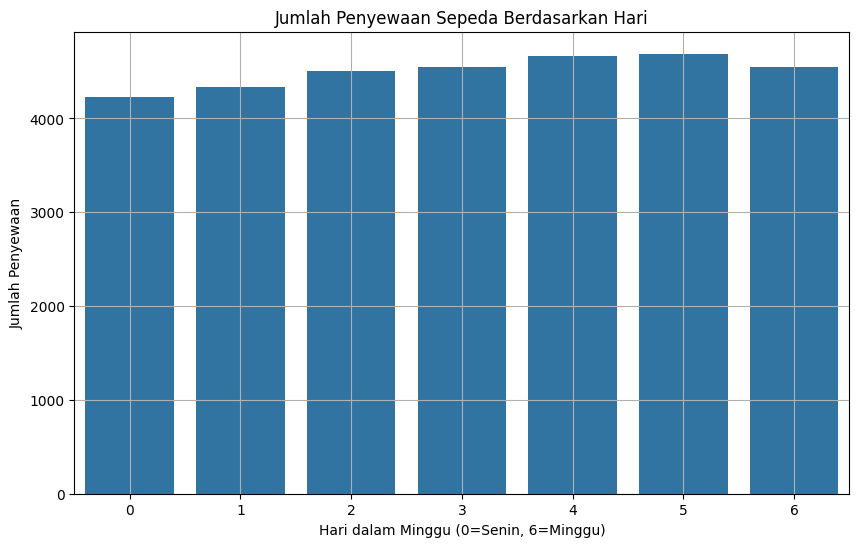

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=day_df, x="weekday", y="cnt", ci=None)
plt.title("Jumlah Penyewaan Sepeda Berdasarkan Hari")
plt.xlabel("Hari dalam Minggu (0=Senin, 6=Minggu)")
plt.ylabel("Jumlah Penyewaan")
plt.grid()
plt.show()

### Visualisasi jumlah penyewaan berdasarkan musim

<ipython-input-39-9e8284069dc3>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=day_df, x="season", y="cnt", ci=None)


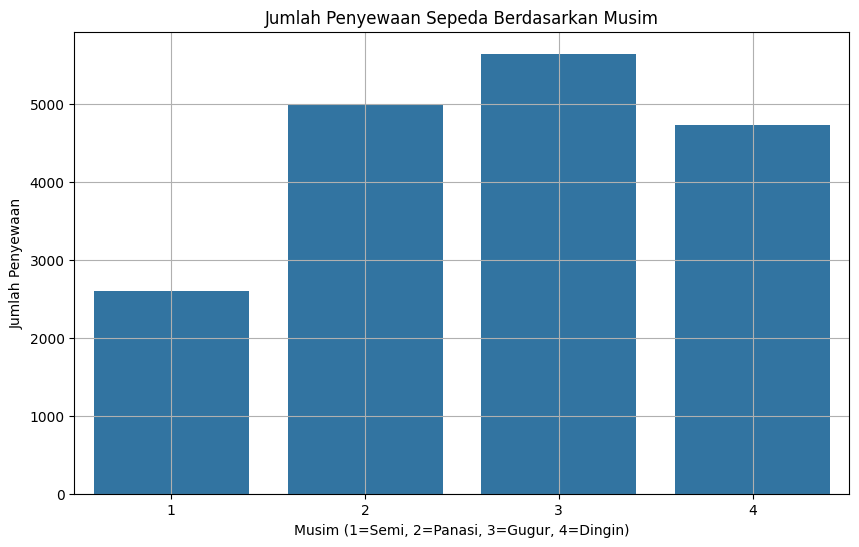

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=day_df, x="season", y="cnt", ci=None)
plt.title("Jumlah Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim (1=Semi, 2=Panasi, 3=Gugur, 4=Dingin)")
plt.ylabel("Jumlah Penyewaan")
plt.grid()
plt.show()


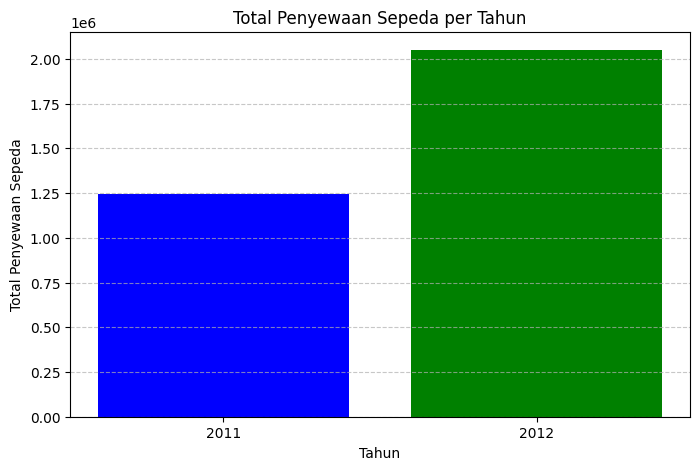

In [48]:
# Load dataset
df = pd.read_csv("day.csv")

if 'yr' in df.columns and 'cnt' in df.columns:
    df['yr'] = df['yr'].map({0: 2011, 1: 2012})


    yearly_rentals = df.groupby('yr')['cnt'].sum()

    # Visualisasi
    plt.figure(figsize=(8, 5))
    colors = ['blue', 'green']  # Warna batang sesuai contoh gambar
    plt.bar(yearly_rentals.index, yearly_rentals.values, color=colors)
    plt.xticks([2011, 2012], ['2011', '2012'])  # Menampilkan hanya tahun 2011 dan 2012
    plt.xlabel('Tahun')
    plt.ylabel('Total Penyewaan Sepeda')
    plt.title('Total Penyewaan Sepeda per Tahun')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Kolom 'yr' atau 'cnt' tidak ditemukan dalam dataset.")


## Conclusion

*  Conclution pertanyaan 1

1.   Suhu dan jumlah pengguna terdaftar adalah faktor utama yang meningkatkan jumlah penyewaan sepeda.
2.  Cuaca buruk, kelembapan tinggi, dan angin kencang sedikit mengurangi penyewaan.
3. Jumlah penyewaan meningkat dari tahun ke tahun.


*   Conclution pertanyaan 2

1.   Penyewaan sepeda paling tinggi saat jam sibuk pagi dan sore, menunjukkan bahwa banyak orang menggunakannya sebagai alat transportasi utama.
2.   Di luar jam sibuk, terutama malam dan dini hari, permintaan menurun drastis.
3. Tren ini bisa digunakan untuk strategi operasional, seperti menyesuaikan jumlah sepeda yang tersedia sesuai jam sibuk.





In [ ]:
day_hour_merged.to_csv("all_data.csv", index=False) # Changed 'all_df' to 'day_hour_merged'